# Predicting Life Expectancy (Regression in PyTorch)

**What this session is (say this on camera):**
> "We've learned the tools. Now we build a COMPLETE, real project together — start to finish — on messy real-world tabular data. This is the 'I do' build. Right after, you'll do a similar project on your own for your portfolio."

**Why this project?**
- It uses only what you already know: dense (`nn.Linear`) layers + the training loop you wrote in Module 2. **No new architecture.**
- The data is genuinely messy: missing values, text columns, wildly different scales. You'll do real preprocessing.
- We'll witness the single biggest lesson in tabular deep learning live: **standardization turns a broken model into a great one.**

**The goal:** predict a country's **life expectancy** (a number) from health & economic indicators. That makes this a **regression** problem.

**Dataset:** WHO Life Expectancy data (`life_exp_data.csv`) — 2938 rows, 22 columns, years 2000–2015 across 193 countries.
> Get it from Kaggle: *"Life Expectancy (WHO)"* by Kumar Rajarshi. Put `life_exp_data.csv` next to this notebook.


## 0. The plan (our checklist for the whole session)

We follow the exact lifecycle from Module 2, on real data:

1. **Load & explore** the raw data
2. **Clean** — fill missing values, encode text columns
3. **Split** into train / validation / test
4. **Standardize** — fit the scaler on TRAIN only (avoid leakage!)
5. **Wrap** in a PyTorch `Dataset` + `DataLoader`
6. **Build** a baseline regression network (`nn.Module`)
7. **Train** with the five sacred steps + a validation loop
8. **Evaluate** with regression metrics (RMSE, MAE, R²)
9. **Experiment** — wider & deeper networks, compare in a table
10. **Save & reload** the best model
11. **Predict** on new data



In [ ]:
from google.colab import drive
drive.mount('/content/drive/MyDrive/life_expectancy')

Mounted at /content/drive/MyDrive/life_expectancy


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'life-expectancy-who' dataset.
Path to dataset files: /kaggle/input/life-expectancy-who


In [ ]:
import os

destination = "/content/drive/MyDrive/life_expectancy"
os.makedirs(destination, exist_ok=True)

In [ ]:

import os
import shutil

source = "/kaggle/input/life-expectancy-who"
destination = "/content/drive/MyDrive/life_expectancy"

os.makedirs(destination, exist_ok=True)

for file_name in os.listdir(source):
    src_file = os.path.join(source, file_name)
    dst_file = os.path.join(destination, file_name)

    if os.path.isfile(src_file):
        shutil.copy2(src_file, dst_file)

print("Done copying safely!")

Done copying safely!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", device)

PyTorch: 2.11.0+cu128 | device: cuda


## 1. Load & explore


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/life_expectancy/Life Expectancy Data.csv")
# Strip leading/trailing whitespace from column names to fix KeyErrors
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
df.head()

Shape: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
# What types do we have, and where are the missing values?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [ ]:
# How much is missing per column?
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

Population                         652
Hepatitis B                        553
GDP                                448
Total expenditure                  226
Alcohol                            194
Income composition of resources    167
Schooling                          163
 thinness 5-9 years                 34
 thinness  1-19 years               34
 BMI                                34
Polio                               19
Diphtheria                          19
Life expectancy                     10
Adult Mortality                     10
dtype: int64



Let's look at the target's distribution.

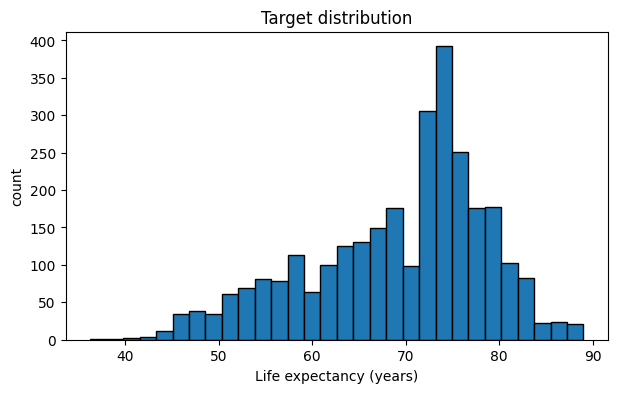

Target ranges from 36.3 to 89.0 years


In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(df["Life expectancy"].dropna(), bins=30, edgecolor="black")
plt.xlabel("Life expectancy (years)"); plt.ylabel("count")
plt.title("Target distribution"); plt.show()

print("Target ranges from", round(df["Life expectancy"].min(), 1),
      "to", round(df["Life expectancy"].max(), 1), "years")

## 2. Clean the data

**Why mean-fill?** It's the simplest reasonable choice and keeps every row. (In a real job you'd consider smarter imputation, but mean-fill is a solid baseline.)


In [ ]:
# --- 2a. Fill missing numeric values with each column's mean ---
numeric_cols = df.select_dtypes(include=["float", "int"]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# --- 2b. Encode text columns (Country, Status) as integers ---
from sklearn.preprocessing import LabelEncoder
object_cols = df.select_dtypes(include=["object"]).columns
print("Text columns to encode:", list(object_cols))

for col in object_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Confirm: no missing values, everything numeric now
print("Any missing left?", df.isnull().sum().sum())
df.head()

Text columns to encode: ['Country', 'Status']
Any missing left? 0


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,0,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,0,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,0,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,0,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## 3. Split into features/target, then train / validation / test

In [ ]:
# Features (X) and target (y)
y = df["Life expectancy"].values.astype("float32")
X = df.drop(columns=["Life expectancy"]).values.astype("float32")
print("X shape:", X.shape, "| y shape:", y.shape)

from sklearn.model_selection import train_test_split
# First carve off the test set (20%), then split the rest into train/val
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

print("train:", X_train.shape[0], "| val:", X_val.shape[0], "| test:", X_test.shape[0])

X shape: (2938, 21) | y shape: (2938,)
train: 1880 | val: 470 | test: 588


## 4. Standardize — the make-or-break step


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # FIT on train (learns mean & std)
X_val   = scaler.transform(X_val)          # only TRANSFORM val
X_test  = scaler.transform(X_test)         # only TRANSFORM test

print("After scaling -> train mean ~0:", round(X_train.mean(), 4),
      "| train std ~1:", round(X_train.std(), 4))

After scaling -> train mean ~0: -0.0 | train std ~1: 1.0


## 5. Wrap in a PyTorch Dataset + DataLoader


In [ ]:
class TabularRegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        # regression target: float, shaped (N, 1) to match a 1-neuron output
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TabularRegressionDataset(X_train, y_train)
val_ds   = TabularRegressionDataset(X_val,   y_val)
test_ds  = TabularRegressionDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)   # shuffle TRAIN
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

xb, yb = next(iter(train_loader))
print("batch X:", xb.shape, "| batch y:", yb.shape)

batch X: torch.Size([32, 21]) | batch y: torch.Size([32, 1])


## 6. Build the baseline regression network

 "Classification vs regression changes only TWO things in the model and loss:
> 1. The output layer has **1 neuron** with **NO activation** (we want any real number, not a probability).
> 2. The loss is **MSELoss** (mean squared error), not CrossEntropyLoss.
> Everything else is the same `nn.Module` you already know."

`n_features` comes straight from the data so we never hard-code the wrong number.


In [ ]:
n_features = X_train.shape[1]   # 21

class RegressionMLP(nn.Module):
    def __init__(self, n_features, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),          # 1 output, NO activation (linear)
        )
    def forward(self, x):
        return self.net(x)

model = RegressionMLP(n_features).to(device)
criterion = nn.MSELoss()                                   # regression loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print(model)

RegressionMLP(
  (net): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 7. Training loop + validation loop

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()             # 1
        preds = model(X)                  # 2
        loss = criterion(preds, y)        # 3
        loss.backward()                   # 4
        optimizer.step()                  # 5
        running += loss.item() * X.size(0)
    return running / len(loader.dataset)

@torch.no_grad()
def eval_loss(model, loader, criterion, device):
    model.eval()
    running = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        running += criterion(model(X), y).item() * X.size(0)
    return running / len(loader.dataset)

print("loops defined.")

loops defined.


In [ ]:
import copy

epochs = 100
patience = 10                 # stop if val loss doesn't improve for 10 epochs
best_val = float("inf")
best_state = None
wait = 0
history = {"train": [], "val": []}

for epoch in range(epochs):
    tr = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va = eval_loss(model, val_loader, criterion, device)
    history["train"].append(tr); history["val"].append(va)

    if va < best_val:                      # improved -> remember this model
        best_val = va
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:                                  # no improvement
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1} (best val MSE {best_val:.3f})")
            break

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | train MSE {tr:8.3f} | val MSE {va:8.3f}")

# restore the best model we saw
model.load_state_dict(best_state)
print("Restored best model. Best val MSE:", round(best_val, 3))

Epoch  10 | train MSE  333.342 | val MSE  344.993
Epoch  20 | train MSE  132.390 | val MSE  145.639
Epoch  30 | train MSE   76.924 | val MSE   80.739
Epoch  40 | train MSE   49.870 | val MSE   51.291
Epoch  50 | train MSE   33.942 | val MSE   35.187
Epoch  60 | train MSE   24.332 | val MSE   25.212
Epoch  70 | train MSE   18.694 | val MSE   18.805
Epoch  80 | train MSE   14.999 | val MSE   15.259
Epoch  90 | train MSE   12.886 | val MSE   13.577
Epoch 100 | train MSE   11.539 | val MSE   11.843
Restored best model. Best val MSE: 11.843


### Plot the learning curves

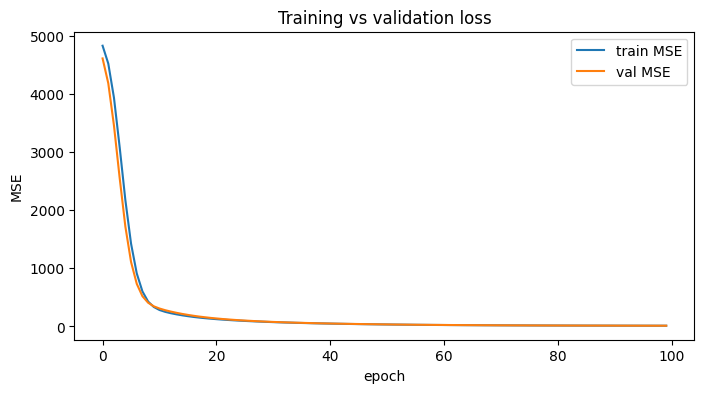

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history["train"], label="train MSE")
plt.plot(history["val"],   label="val MSE")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend()
plt.title("Training vs validation loss"); plt.show()

## 8. Evaluate with regression metrics

For regression we don't report accuracy. We report:
> - **RMSE** — average error in the SAME units as the target (years of life). Most intuitive.
> - **MAE** — average absolute error, less sensitive to outliers.
> - **R²** — fraction of variance explained (1.0 = perfect, 0 = no better than guessing the mean).
> This is the final exam on the untouched test set.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    preds, trues = [], []
    for X, y in loader:
        preds.append(model(X.to(device)).cpu().numpy())
        trues.append(y.numpy())
    return np.vstack(preds).ravel(), np.vstack(trues).ravel()

y_pred, y_true = predict(model, test_loader, device)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
print(f"Test RMSE: {rmse:.2f} years")
print(f"Test MAE:  {mae:.2f} years")
print(f"Test R²:   {r2:.3f}")

Test RMSE: 3.51 years
Test MAE:  2.61 years
Test R²:   0.858


### Visualize predictions vs reality


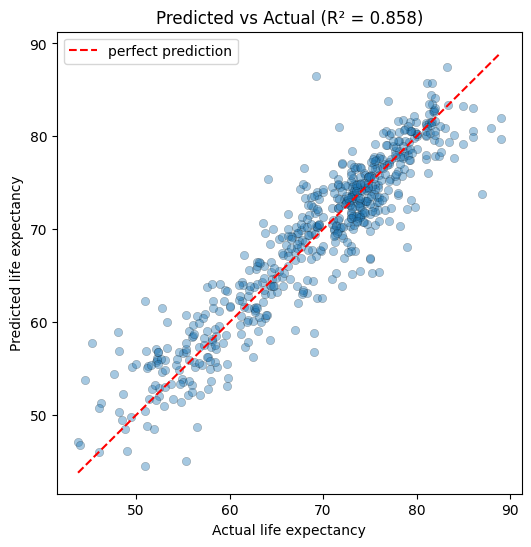

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.4, edgecolor="k", linewidth=0.3)
lims = [y_true.min(), y_true.max()]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("Actual life expectancy"); plt.ylabel("Predicted life expectancy")
plt.title(f"Predicted vs Actual (R² = {r2:.3f})"); plt.legend(); plt.show()

## 9. Experiment — does a wider or deeper network help?




In [ ]:
def build_and_train(model, tag, epochs=60):
    """Train a model with EarlyStopping and return its test metrics."""
    model = model.to(device)
    crit = nn.MSELoss()
    opt = optim.Adam(model.parameters(), lr=1e-3)
    best, best_state, wait = float("inf"), None, 0
    for ep in range(epochs):
        train_one_epoch(model, train_loader, crit, opt, device)
        va = eval_loss(model, val_loader, crit, device)
        if va < best:
            best, best_state, wait = va, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= 10:
                break
    model.load_state_dict(best_state)
    yp, yt = predict(model, test_loader, device)
    return {
        "model": tag,
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "MAE":  mean_absolute_error(yt, yp),
        "R2":   r2_score(yt, yp),
    }

In [ ]:
# Three architectures, same data, same training recipe
class WiderMLP(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n, 128), nn.ReLU(), nn.Linear(128, 1))
    def forward(self, x): return self.net(x)

class DeeperMLP(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x): return self.net(x)

results = [
    build_and_train(RegressionMLP(n_features), "baseline (1x64)"),
    build_and_train(WiderMLP(n_features),      "wider (1x128)"),
    build_and_train(DeeperMLP(n_features),     "deeper (64-64-32)"),
]

pd.DataFrame(results).set_index("model").round(3)

,RMSE,MAE,R2
model,,,
baseline (1x64),5.298,4.118,0.676
wider (1x128),4.362,3.339,0.780
deeper (64-64-32),2.851,2.058,0.906


## 10. Save & reload the best model


In [ ]:
import joblib

# Save model weights AND the fitted scaler (both are needed to predict later)
torch.save(model.state_dict(), "life_exp_model.pth")
joblib.dump(scaler, "life_exp_scaler.pkl")
print("Saved model + scaler.")

# Reload and confirm it still works
reloaded = RegressionMLP(n_features).to(device)
reloaded.load_state_dict(torch.load("life_exp_model.pth", map_location=device))
reloaded.eval()
yp, yt = predict(reloaded, test_loader, device)
print("Reloaded R²:", round(r2_score(yt, yp), 3))

Saved model + scaler.
Reloaded R²: 0.858


## 11. Predict on a new (hypothetical) country


In [ ]:
# Take one real test row as a stand-in for "new data" (already scaled here)
new_sample = X_test[0:1]                       # shape (1, n_features), already scaled
new_tensor = torch.tensor(new_sample, dtype=torch.float32).to(device)

reloaded.eval()
with torch.no_grad():
    prediction = reloaded(new_tensor).item()

print(f"Predicted life expectancy: {prediction:.1f} years")
print(f"Actual value:              {y_test[0]:.1f} years")

Predicted life expectancy: 71.2 years
Actual value:              73.7 years


## ✅ Wrap-up & what we built

**The reusable recipe (this works for ANY tabular problem):**
1. Load & explore → 2. Clean (fill + encode) → 3. Split 3 ways → 4. **Standardize (fit on train only)** → 5. Dataset/DataLoader → 6. Model (output layer + loss match the task) → 7. Train + validate + early stop → 8. Evaluate with the right metrics → 9. Experiment → 10. Save model **and** scaler → 11. Predict.

**Regression vs classification cheat-sheet:**

| | Output layer | Loss | Metric | Target dtype |
|---|---|---|---|---|
| **Regression** (this project) | `Linear(h, 1)`, no activation | `MSELoss` | RMSE / MAE / R² | `float`, shape `(N,1)` |
| **Binary classification** | `Linear(h, 1)` | `BCEWithLogitsLoss` | accuracy / F1 | `float` 0/1 |
| **Multi-class** | `Linear(h, C)` | `CrossEntropyLoss` | accuracy / F1 | `long` |

---
## 🎯 Your turn — Solo Portfolio Project
Now you'll build a project like this **on your own**, on a dataset **you choose**, and add it to your portfolio.
